# 06 - Hydrological context and snowmelt timing

Addresses two reviewer comments:

> *"Add hydrological context—link snow trends to streamflow, groundwater, or reservoir levels."*
> *"Add snowmelt timing analysis—analyze changes in melt onset, peak snowpack timing."*

**Section 1** quantifies the loss of seasonal snow water storage from data already in hand -
no new download required - and converts it into a water volume for the study area. This is the
strongest hydrological statement obtainable from the existing dataset.

**Section 2** shows why melt timing *cannot* be resolved from the monthly composites, and sets
up the daily analysis that can. `notebook 07, section 2` produces the daily-resolution
snow onset, melt-out and snow cover duration series; run it and the notebook picks up the export.

**Section 3** is the optional extension to modelled runoff and to GRACE terrestrial water
storage via `notebook 07, section 3`.

In [7]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT   = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA   = os.path.join(ROOT, "data", "derived")
FIGDIR = os.path.join(ROOT, "figures")
RESDIR = os.path.join(ROOT, "results")

# Study area from the manuscript (mountainous Kurdistan Region of Iraq)
AREA_KM2 = 26155.5

snow = pd.read_csv(os.path.join(DATA, "snow_seasonal.csv"))
clim = pd.read_csv(os.path.join(DATA, "climate_seasonal.csv"))
monthly = pd.read_csv(os.path.join(DATA, "snow_monthly.csv"))
df = snow.merge(clim, on="season")

def sen(y, x):
    y = np.asarray(y, float); x = np.asarray(x, float)
    ok = np.isfinite(y); y, x = y[ok], x[ok]
    sl = [(y[j] - y[i]) / (x[j] - x[i]) for i in range(len(y)) for j in range(i + 1, len(y))]
    tau, p = stats.kendalltau(x, y)
    return float(np.median(sl)), float(tau), float(p)

print(f"study area: {AREA_KM2:,.1f} km²   seasons: {len(df)}")

study area: 26,155.5 km²   seasons: 24


## 1. Loss of seasonal snow water storage

ERA5-Land snow water equivalent is an area-averaged depth in mm. Multiplying by the study area
converts it into a stored water volume:

$$V\ [\mathrm{million\ m^3}] = \mathrm{SWE\ [mm]} \times \frac{A\ [\mathrm{km^2}]}{1000}$$

so 1 mm of area-mean SWE over 26,155 km² is 26.2 million m³ of water held in the snowpack.

In [8]:
MM_TO_MCM = AREA_KM2 / 1000.0          # 1 mm over the study area -> million m3

rows = []
for col, label, unit in [("swe_max", "Seasonal maximum snow water equivalent", "mm w.e."),
                         ("snowfall_ondjfm", "Seasonal snowfall", "mm w.e."),
                         ("precip_ondjfm", "Seasonal total precipitation", "mm"),
                         ("snowfall_fraction_ondjfm", "Snowfall fraction", "–")]:
    sl, tau, p = sen(df[col], df["season"])
    a = df[df.season <= 2012][col].mean()
    b = df[df.season >= 2013][col].mean()
    rows.append(dict(variable=label, unit=unit, mean=df[col].mean(),
                     sen_per_yr=sl, change_over_record=sl * 23, tau=tau, p=p,
                     first_half=a, second_half=b, pct_change=(b - a) / abs(a) * 100))
hyd = pd.DataFrame(rows)
hyd.to_csv(os.path.join(RESDIR, "table7_snow_water_storage.csv"), index=False)
print(hyd.round(3).to_string(index=False))

swe_a = df[df.season <= 2012]["swe_max"].mean()
swe_b = df[df.season >= 2013]["swe_max"].mean()
print(f"""
Seasonal snow water storage, area-integrated over {AREA_KM2:,.0f} km²
  2000/01-2011/12 : {swe_a:6.1f} mm w.e.  =  {swe_a*MM_TO_MCM:7.0f} million m³  ({swe_a*MM_TO_MCM/1000:.2f} km³)
  2012/13-2023/24 : {swe_b:6.1f} mm w.e.  =  {swe_b*MM_TO_MCM:7.0f} million m³  ({swe_b*MM_TO_MCM/1000:.2f} km³)
  change          : {swe_b-swe_a:+6.1f} mm w.e.  =  {(swe_b-swe_a)*MM_TO_MCM:+7.0f} million m³  ({(swe_b-swe_a)/swe_a*100:+.1f}%)
""")

                              variable    unit    mean  sen_per_yr  change_over_record    tau     p  first_half  second_half  pct_change
Seasonal maximum snow water equivalent mm w.e.  62.805      -1.506             -34.631 -0.196 0.191      72.211       53.399     -26.051
                     Seasonal snowfall mm w.e. 160.371      -2.623             -60.322 -0.333 0.023     180.147      140.596     -21.955
          Seasonal total precipitation      mm 706.955      -0.644             -14.801 -0.014 0.941     668.047      745.863      11.648
                     Snowfall fraction       –   0.233      -0.004              -0.103 -0.348 0.017       0.272        0.195     -28.347

Seasonal snow water storage, area-integrated over 26,156 km²
  2000/01-2011/12 :   72.2 mm w.e.  =     1889 million m³  (1.89 km³)
  2012/13-2023/24 :   53.4 mm w.e.  =     1397 million m³  (1.40 km³)
  change          :  -18.8 mm w.e.  =     -492 million m³  (-26.1%)



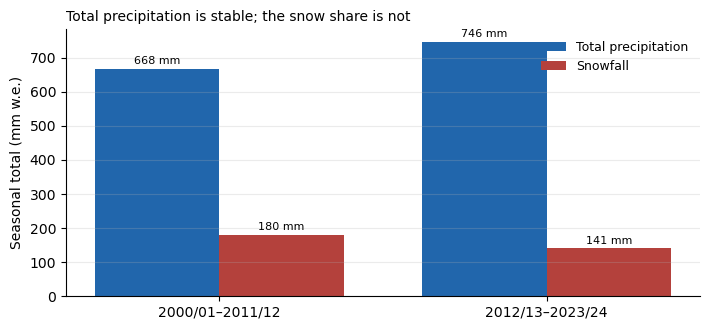

In [9]:
# The phase-shift result: precipitation is NOT declining, snowfall is.
fig, ax = plt.subplots(figsize=(7.2, 3.4))
w = 0.38
x = np.arange(2)
for i, (col, lab, c) in enumerate([("precip_ondjfm", "Total precipitation", "#2166AC"),
                                   ("snowfall_ondjfm", "Snowfall", "#B4413C")]):
    vals = [df[df.season <= 2012][col].mean(), df[df.season >= 2013][col].mean()]
    b = ax.bar(x + (i - .5) * w, vals, w, color=c, label=lab)
    ax.bar_label(b, fmt="%.0f mm", fontsize=8, padding=2)
ax.set_xticks(x, ["2000/01–2011/12", "2012/13–2023/24"])
ax.set_ylabel("Seasonal total (mm w.e.)")
ax.set_title("Total precipitation is stable; the snow share is not", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=9); ax.grid(axis="y", alpha=.25)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "figS2_precip_vs_snowfall.png"), dpi=400)
plt.show()

### What this supports in the manuscript

- Total water input to the mountains has **not** declined (p = 0.94); the snow share has.
- The seasonal snow reservoir has lost roughly a quarter of its volume between the two halves
  of the record.
- The hydrological consequence is a **shift in timing**, not in total volume: water that was
  stored until spring now runs off during winter storms.
- MODIS SCA correlates with ERA5-Land maximum SWE at r = 0.81, so the published snow-cover
  metrics are usable proxies for this storage term.

**Do not** claim a streamflow change without gauge data. Gauged discharge for the Greater Zab,
Lesser Zab and Diyala is not in the public domain; state that as a limitation.

## 2. Snowmelt timing

### 2a. What the monthly composites can and cannot show

In [10]:
rows = []
for s, g in monthly.groupby("season"):
    g = g.sort_values("season_month")
    sca, mon = g["sca"].values, g["season_month"].values
    thr = 0.10 * np.nanmax(sca)
    on  = mon[sca >= thr][0]  if (sca >= thr).any() else np.nan
    off = mon[sca >= thr][-1] if (sca >= thr).any() else np.nan
    rows.append(dict(season=s, onset_month=on, peak_month=mon[np.nanargmax(sca)],
                     meltout_month=off, duration_months=off - on + 1,
                     centroid=float((mon * np.nan_to_num(sca)).sum() / np.nansum(sca))))
tim = pd.DataFrame(rows)
tim.to_csv(os.path.join(RESDIR, "table8_melt_timing_monthly.csv"), index=False)

print("Melt-timing metrics at MONTHLY resolution (1 = October ... 6 = March)\n")
for col in ["onset_month", "peak_month", "meltout_month", "duration_months", "centroid"]:
    sl, tau, p = sen(tim[col], tim["season"])
    print(f"{col:17s} mean = {tim[col].mean():5.2f}   Sen = {sl:+.4f} month/yr "
          f"({sl*10:+.2f}/decade)   tau = {tau:+.2f}, p = {p:.3f}")
print(f"\nPeak month is February in {(tim.peak_month == 5).sum()} of {len(tim)} seasons.")
print("\nAll timing metrics are quantised to whole months, so a shift of one to two weeks - the "
      "magnitude reported for comparable mountain regions - is undetectable here. This is a "
      "resolution limit, not evidence of no change.")

Melt-timing metrics at MONTHLY resolution (1 = October ... 6 = March)

onset_month       mean =  2.83   Sen = +0.0000 month/yr (+0.00/decade)   tau = -0.09, p = 0.588
peak_month        mean =  4.33   Sen = +0.0000 month/yr (+0.00/decade)   tau = +0.03, p = 0.845
meltout_month     mean =  6.00   Sen = +0.0000 month/yr (+0.00/decade)   tau = +nan, p = nan
duration_months   mean =  4.17   Sen = +0.0000 month/yr (+0.00/decade)   tau = +0.09, p = 0.588
centroid          mean =  4.38   Sen = +0.0056 month/yr (+0.06/decade)   tau = +0.12, p = 0.446

Peak month is February in 8 of 24 seasons.

All timing metrics are quantised to whole months, so a shift of one to two weeks - the magnitude reported for comparable mountain regions - is undetectable here. This is a resolution limit, not evidence of no change.


### 2b. Daily-resolution melt timing (Earth Engine)

Run `notebook 07, section 2`, download `MODIS_melt_timing.csv` into `data/`, then run
the cell below. It gives snow onset day, melt-out day and snow cover duration counted from
1 October, at 500 m and daily resolution - the analysis the reviewer actually asked for.

In [11]:
mt_path = os.path.join(DATA, "MODIS_melt_timing.csv")
if os.path.exists(mt_path):
    mt = pd.read_csv(mt_path).sort_values("season_start").reset_index(drop=True)
    print("Daily-resolution melt timing (days from 1 October)\n")
    out = []
    for col in ["onset_doy", "meltout_doy", "scd_days"]:
        sl, tau, p = sen(mt[col], mt["season_start"])
        out.append(dict(metric=col, mean_days=mt[col].mean(), sen_days_per_yr=sl,
                        days_per_decade=sl * 10, change_over_record=sl * 23, tau=tau, p=p))
        print(f"{col:12s} mean = {mt[col].mean():6.1f} d   Sen = {sl:+.3f} d/yr "
              f"({sl*10:+.1f} d/decade)   tau = {tau:+.2f}, p = {p:.3f}")
    pd.DataFrame(out).to_csv(os.path.join(RESDIR, "table9_melt_timing_daily.csv"), index=False)

    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2))
    for ax, col, lab in zip(axes, ["onset_doy", "meltout_doy", "scd_days"],
                            ["Snow onset (days from 1 Oct)", "Melt-out (days from 1 Oct)",
                             "Snow cover duration (days)"]):
        ax.plot(mt.season_start, mt[col], "o-", color="#3D4852", lw=1.1, ms=3.5)
        b, a = np.polyfit(mt.season_start, mt[col], 1)
        ax.plot(mt.season_start, a + b * mt.season_start, "--", color="#B4413C", lw=1.5)
        ax.set_xlabel("Season (starting year)"); ax.set_ylabel(lab); ax.grid(alpha=.22)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGDIR, "figS3_melt_timing_daily.png"), dpi=400)
    plt.show()
else:
    print("MODIS_melt_timing.csv not found - run notebook 07 section 2 first.")

MODIS_melt_timing.csv not found - run notebook 07 section 2 first.


## 3. Optional: modelled runoff and GRACE water storage

Run `notebook 07, section 3` and place `ERA5Land_KRI_hydrology.csv` and
`GRACE_KRI_TWS.csv` in `data/`. The cell below relates snow cover to modelled snowmelt and
runoff and to GRACE terrestrial water storage, which includes the groundwater component the
reviewer mentions.

Treat GRACE cautiously: its footprint (~300 km) is much larger than the study area, so it
represents the wider basin rather than the mountain block alone, and there is a data gap
between the two missions in 2017–2018.

In [12]:
# ERA5-Land hydrology: look in data/ first, then results/ (in case the GEE export landed there)
def _find(name):
    for d in (DATA, RESDIR):
        q = os.path.join(d, name)
        if os.path.exists(q):
            return q
    return None

hyd_path, grace_path = _find("ERA5Land_KRI_hydrology.csv"), _find("GRACE_KRI_TWS.csv")

if hyd_path:
    h = pd.read_csv(hyd_path)
    FLUX = ["snowmelt_sum", "runoff_sum", "surface_runoff_sum",
            "sub_surface_runoff_sum", "total_evaporation_sum"]
    for c in FLUX:
        if c in h:
            h[c] = h[c] * 1000.0                      # ERA5-Land monthly sums are in m
    # water year Oct-Sep, labelled by its ending year; wm = 1 (Oct) .. 12 (Sep)
    h["wy"] = np.where(h.month >= 10, h.year + 1, h.year)
    h["wm"] = np.where(h.month >= 10, h.month - 9, h.month + 3)
    h = h.groupby("wy").filter(lambda g: len(g) == 12)
    print(f"{h.wy.nunique()} complete water years: {h.wy.min()}-{h.wy.max()}")

    ann = h.groupby("wy").agg(snowmelt=("snowmelt_sum", "sum"),
                              runoff=("runoff_sum", "sum"),
                              surface_runoff=("surface_runoff_sum", "sum"),
                              subsurface_runoff=("sub_surface_runoff_sum", "sum"))
    # centre of timing: runoff-weighted mean month, in months from 1 October
    ct = h.groupby("wy").apply(
        lambda g: (g.wm * g.runoff_sum.clip(lower=0)).sum() / g.runoff_sum.clip(lower=0).sum(),
        include_groups=False)
    ann["runoff_centre_of_timing"] = ct
    ann["winter_share"] = h[h.wm.isin([3, 4, 5])].groupby("wy").runoff_sum.sum() / ann.runoff
    ann["spring_share"] = h[h.wm.isin([7, 8, 9])].groupby("wy").runoff_sum.sum() / ann.runoff
    ann.to_csv(os.path.join(RESDIR, "table10_hydrology_annual.csv"))

    print("\nTrends (Theil-Sen + Mann-Kendall, water years)\n")
    for c in ann.columns:
        sl, tau, p_ = sen(ann[c], ann.index.values)
        print(f"{c:24s} mean = {ann[c].mean():9.3f}   Sen = {sl:+8.4f}/yr   "
              f"tau = {tau:+.2f}, p = {p_:.3f}")

    print("\nFirst vs second half of the record\n")
    for c in ["snowmelt", "runoff", "runoff_centre_of_timing", "winter_share", "spring_share"]:
        a, b = ann[ann.index <= 2012][c].mean(), ann[ann.index >= 2013][c].mean()
        print(f"{c:24s} {a:9.3f} -> {b:9.3f}   ({(b - a) / abs(a) * 100:+.1f}%)")

    j = df.set_index("season").join(ann, how="inner").dropna(subset=["snowmelt"])
    print(f"\nSnow metrics vs modelled hydrology (n = {len(j)})\n")
    for a_, b_ in [("sca_mean", "snowmelt"), ("swe_max", "snowmelt"),
                   ("sca_mean", "runoff"), ("sca_mean", "spring_share"),
                   ("t2m_djfm", "runoff_centre_of_timing")]:
        r, p_ = stats.pearsonr(j[a_], j[b_])
        print(f"  {a_:10s} vs {b_:24s} r = {r:+.3f}, p = {p_:.4f}")
    print("\nInterpretation: a strong SCA-snowmelt correlation validates the snow metrics as a "
          "proxy for melt water supply. A non-significant trend in total runoff alongside a "
          "shifting seasonal partition is the signature of a phase change rather than a volume "
          "change - but report the partition as suggestive unless its trend is significant.")
else:
    print("ERA5Land_KRI_hydrology.csv not found in data/ or results/ - "
          "run notebook 07 section 3, or notebook 07, section 3")

if grace_path:
    g = pd.read_csv(grace_path)
    g["season"] = np.where(g["month"] >= 10, g["year"] + 1, g["year"])
    anng = g.groupby("year")["lwe_thickness"].mean()
    sl, tau, p_ = sen(anng.values, anng.index.values)
    print(f"\nGRACE terrestrial water storage: Sen = {sl:+.3f} cm/yr, tau = {tau:+.2f}, p = {p_:.4f}")
    jg = df.set_index("season").join(g.groupby("season")["lwe_thickness"].mean(), how="inner").dropna()
    if len(jg) > 8:
        r, p_ = stats.pearsonr(jg["sca_mean"], jg["lwe_thickness"])
        print(f"SCA vs GRACE TWS: r = {r:.2f}, p = {p_:.4f}, n = {len(jg)}")
    print("Caveat: the GRACE footprint (~300 km) is much larger than the study area and there is "
          "a gap between the two missions in 2017-2018.")
else:
    print("\nGRACE_KRI_TWS.csv not found - run notebook 07 section 3.")

ERA5Land_KRI_hydrology.csv not found - run notebook 07 section 3 first.
GRACE_KRI_TWS.csv not found - run notebook 07 section 3 first.
